In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import math
from PIL import Image
import json
import time

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df["time_sec"] = df["time"].astype(str).str[:8]
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,samsung_rotation_vector_std_value3,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,attention,subject_id,time_sec
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,0.000083,69.0,0.0,94.0,male,26.0,white,2.75,group01_subject_01,10:59:49
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,26.0,white,2.75,group01_subject_01,10:59:49
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,26.0,white,2.75,group01_subject_01,10:59:49
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,26.0,white,2.75,group01_subject_01,10:59:49
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,26.0,white,2.75,group01_subject_01,10:59:49


In [50]:
# df.isna().sum().head(60)

In [51]:
df[['attention', 'age', 'image_path']].isna().sum()

attention     0
age           0
image_path    0
dtype: int64

In [52]:
# keep only 1 record per experiment
df_sec = (df.sort_values("time")
      .groupby(["subject_id", "time_sec"])
      .first()
      .reset_index()
)

In [53]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# transform = transforms.Compose([
#     transforms.Resize((224, 224)),

#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(10),
#     transforms.ColorJitter(
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.1
#     ),

#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

### For zipped images

In [54]:
# import zipfile
# from io import BytesIO
# import os


# class DipserImageDataset(Dataset):
#     def __init__(self, df, transform=None):
#         self.df = df.reset_index(drop=True)
#         self.transform = transform
#         self.zip_cache = {}

#     def __len__(self):
#         return len(self.df)

#     def _get_zip(self, zip_path):
#         if zip_path not in self.zip_cache:
#             self.zip_cache[zip_path] = zipfile.ZipFile(zip_path, 'r')
#         return self.zip_cache[zip_path]

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         image_path = row["image_path"]

#         subject_dir = os.path.dirname(os.path.dirname(image_path))
#         zip_path = os.path.join(subject_dir, "images.zip")

#         filename = os.path.basename(image_path)

#         z = self._get_zip(zip_path)

#         with z.open(filename) as f:
#             img = Image.open(BytesIO(f.read())).convert("RGB")

#         if self.transform:
#             img = self.transform(img)

#         label = torch.tensor(row["attention"], dtype=torch.float32)

#         return img, label, idx

### For raw images

In [55]:
# class DipserImageDataset(Dataset):
#     def __init__(self, df, transform=None):
#         self.df = df.reset_index(drop=True)
#         self.transform = transform

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]

#         img = Image.open(row["image_path"]).convert("RGB")

#         if self.transform:
#             img = self.transform(img)

#         label = torch.tensor(row["attention"], dtype=torch.float32)

#         return img, label, idx

### Hybrid loading (group 01 zipped images, groups 02, 03 raw

Purpose:
* free inodes (group01 compressed)
* keep speed (group02/03 raw) and avoid full slowdown of TAR/ZIP

In [65]:
import zipfile
from io import BytesIO
import os

class DipserImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.zip_cache = {}

    def __len__(self):
        return len(self.df)

    def _get_zip(self, zip_path):
        if zip_path not in self.zip_cache:
            self.zip_cache[zip_path] = zipfile.ZipFile(zip_path, 'r')
        return self.zip_cache[zip_path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]

        subject_dir = os.path.dirname(os.path.dirname(image_path))
        zip_path = os.path.join(subject_dir, "images.zip")

        filename = os.path.basename(image_path)

        if os.path.exists(zip_path):
            z = self._get_zip(zip_path)
            with z.open(filename) as f:
               img = Image.open(BytesIO(f.read())).convert("RGB")
            #img = Image.open(f).convert("RGB")
        else:
            img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["attention"], dtype=torch.float32)

        return img, label, idx

### Train Test Split

In [66]:
subject_df = df_sec[['subject_id', 'gender_name']].drop_duplicates()

train_sub, test_sub = train_test_split(
    subject_df,
    test_size=0.2,
    stratify=subject_df['gender_name'],
    random_state=42
)

train_subjects = train_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sec[df_sec["subject_id"].isin(train_subjects)]
test_df  = df_sec[df_sec["subject_id"].isin(test_subjects)]

In [67]:
train_dataset = DipserImageDataset(train_df, transform)
test_dataset  = DipserImageDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
#train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

#test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)

### Training

In [68]:
# resnet50
# class AttentionCNN(nn.Module):
#     def __init__(self, freeze_backbone=True):
#         super().__init__()

#         self.backbone = models.resnet50(pretrained=True)

#         if freeze_backbone:
#             for p in self.backbone.parameters():
#                 p.requires_grad = False

#         in_features = self.backbone.fc.in_features
#         self.backbone.fc = nn.Identity()

#         self.head = nn.Sequential(
#             nn.Linear(in_features, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.4),
        
#             nn.Linear(256, 64),
#             nn.ReLU(),
        
#             nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         x = self.backbone(x)      # (B, 2048)
#         x = self.head(x)          # (B, 1)
#         return x.squeeze(1)


# # resnet50
class AttentionCNN(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.backbone(x)      # (B, 2048)
        x = self.head(x)          # (B, 1)
        return x.squeeze(1)


# efficientnet_b0
# class AttentionCNN(nn.Module):
#     def __init__(self, freeze_backbone=True):
#         super().__init__()

#         self.backbone = models.efficientnet_b0(pretrained=True)

#         if freeze_backbone:
#             for p in self.backbone.parameters():
#                 p.requires_grad = False

#         in_features = self.backbone.classifier[1].in_features
#         self.backbone.classifier = nn.Identity()

#         self.head = nn.Sequential(
#             nn.Linear(in_features, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, 1)
#         )

#     def forward(self, x):
#         x = self.backbone(x)        # (B, 1280)
#         x = self.head(x)            # (B, 1)
#         return x.squeeze(1)         # (B,)



In [69]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = model(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    # compute metrics
    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [70]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [71]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [72]:
model_path = "models/resnet50_baseline.pt"
model_results = "results/resnet50_results.json"
model_figs = "figs/resnet50_training_curves.png"

In [73]:
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionCNN(freeze_backbone=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [74]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, test_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.1694
Train MAE: 0.2991 | Train RMSE: 0.4116
Val MAE: 0.3435 | Val RMSE: 0.4426



Epoch 2
Train Loss: 0.1071
Train MAE: 0.2551 | Train RMSE: 0.3273
Val MAE: 0.3355 | Val RMSE: 0.4363



Epoch 3
Train Loss: 0.0986
Train MAE: 0.2448 | Train RMSE: 0.3141
Val MAE: 0.3238 | Val RMSE: 0.4217



Epoch 4
Train Loss: 0.0924
Train MAE: 0.2372 | Train RMSE: 0.3038
Val MAE: 0.3444 | Val RMSE: 0.4432
EarlyStopping counter: 1/7



Epoch 5
Train Loss: 0.0865
Train MAE: 0.2308 | Train RMSE: 0.2941
Val MAE: 0.3364 | Val RMSE: 0.4367
EarlyStopping counter: 2/7



Epoch 6
Train Loss: 0.0823
Train MAE: 0.2246 | Train RMSE: 0.2869
Val MAE: 0.3454 | Val RMSE: 0.4485
EarlyStopping counter: 3/7



Epoch 7
Train Loss: 0.0784
Train MAE: 0.2194 | Train RMSE: 0.2800
Val MAE: 0.3395 | Val RMSE: 0.4348
EarlyStopping counter: 4/7



Epoch 8
Train Loss: 0.0677
Train MAE: 0.2044 | Train RMSE: 0.2602
Val MAE: 0.3434 | Val RMSE: 0.4452
EarlyStopping counter: 5/7



Epoch 9
Train Loss: 0.0642
Train MAE: 0.1992 | Train RMSE: 0.2533
Val MAE: 0.3542 | Val RMSE: 0.4574
EarlyStopping counter: 6/7



Epoch 10
Train Loss: 0.0621
Train MAE: 0.1962 | Train RMSE: 0.2493
Val MAE: 0.3416 | Val RMSE: 0.4414
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 2942.454008579254


### Evaluation

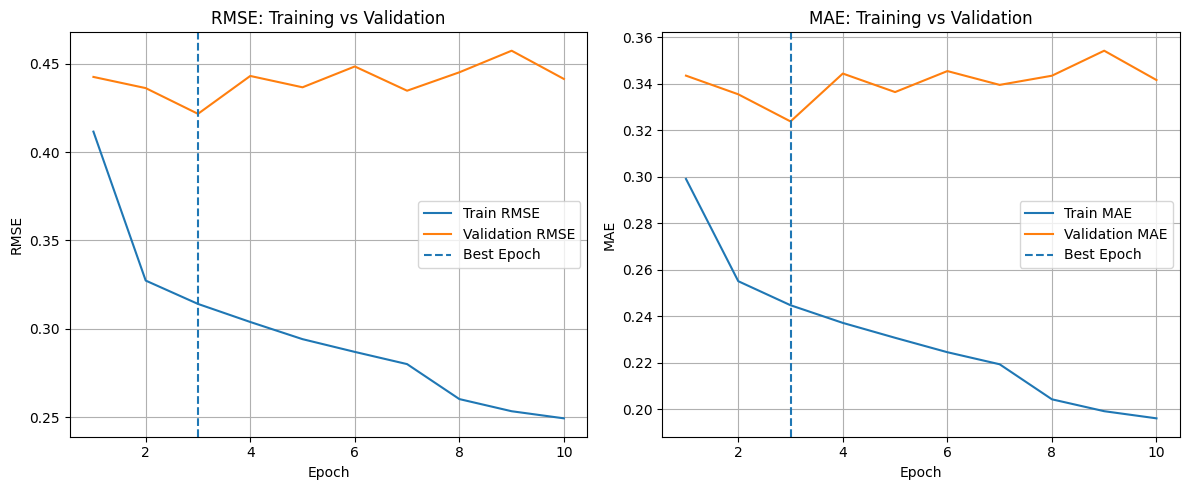

In [75]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

In [76]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap

In [77]:
def collect_predictions(model, df, loader):
    model.eval()

    results = []

    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for imgs, labels, idx in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            batch_time = end - start

            total_time += batch_time
            total_samples += imgs.size(0)

            preds = preds.cpu().numpy()

            for i in range(len(preds)):
                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "gender": row["gender_name"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    # --- metrics ---
    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))
    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, mae, rmse, latency_per_batch, latency_per_sample

In [78]:
def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics

In [79]:
def replace_nan(d, value=None):
    if isinstance(d, dict):
        return {
            k: replace_nan(v, value)
            for k, v in d.items()
        }
    if isinstance(d, float) and math.isnan(d):
        return value
    return d

In [80]:
# model_path = "models/resnet50_baseline.pt"
# model_results = "results/resnet50_results.json"

model = AttentionCNN(freeze_backbone=False).to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.load_state_dict(torch.load(model_path))
model.eval()

/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/scratch-local/cfragkiadakis.22479007/ipykernel_2614414/1881383707.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/

AttentionCNN(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
    

In [81]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}
clean_results = replace_nan(results, value=None)
with open(model_results, "w") as f:
    json.dump(clean_results, f, indent=4)

Evaluating: 100%|██████████| 286/286 [00:33<00:00,  8.45it/s]
/scratch-local/cfragkiadakis.22479007/ipykernel_2614414/38029496.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22479007/ipykernel_2614414/38029496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22479007

In [82]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.33114, 'male': 0.30755}

Worst-group MAE: 0.33114
Gap: 0.0236


In [83]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.32879, '(17, 20]': 0.28858, '(20, 22]': 0.36392, '(22, 26]': 0.32628, '(26, 44]': nan}

Worst-group MAE: 0.36392
Gap: 0.07533
